In [23]:
import os

# 1. กำหนดตำแหน่งโฟลเดอร์ (แนะนำให้ใส่ r นำหน้าเพื่อเป็น Raw String)
path = r'D:\Lecture\Project\1-68\Chicken\PINN-CFD'

# 2. ทำการย้าย
try:
    os.chdir(path)
    print(f"ย้ายโฟลเดอร์สำเร็จ!\nตำแหน่งปัจจุบัน: {os.getcwd()}")
except FileNotFoundError:
    print("หาโฟลเดอร์ไม่เจอครับ! รบกวนตรวจสอบพาธอีกครั้ง")

ย้ายโฟลเดอร์สำเร็จ!
ตำแหน่งปัจจุบัน: D:\Lecture\Project\1-68\Chicken\PINN-CFD


In [ ]:
import pandas as pd
import numpy as np
import os

def load_and_combine_data(file_100, file_060, file_030):
    print("--- 🔄 กำลังเตรียมและรวมข้อมูล Parametrized PINN ---")
    
    # 1. ตรวจสอบว่าไฟล์ทั้ง 3 มีอยู่จริง
    files = [file_100, file_060, file_030]
    for f in files:
        if not os.path.exists(f):
            print(f"❌ Error: หาไฟล์ '{f}' ไม่เจอ กรุณาตรวจสอบชื่อไฟล์และโฟลเดอร์ครับ")
            return None

    # 2. ฟังก์ชันย่อยสำหรับโหลดและทำความสะอาดไฟล์เดี่ยว
    def process_single_file(filepath, speed_value):
        df = pd.read_csv(filepath)
        df.columns = df.columns.str.strip().str.lower() # จัดการชื่อคอลัมน์
        df = df.dropna() # ลบค่าว่าง
        
        # คัดมาเฉพาะคอลัมน์ที่ใช้
        cols = ['x-coordinate', 'y-coordinate', 'z-coordinate', 
                'x-velocity', 'y-velocity', 'z-velocity', 'pressure']
        df = df[cols].copy()
        
        # *** หัวใจสำคัญ: เพิ่มคอลัมน์ความเร็วพัดลม (fan_speed) ***
        df['fan_speed'] = speed_value
        return df

    # 3. โหลดและใส่ค่า Parameter ให้แต่ละเคส
    print(f"กำลังโหลดเคส 100% จาก: {file_100} ...")
    df_100 = process_single_file(file_100, speed_value=1.0)
    
    print(f"กำลังโหลดเคส 60%  จาก: {file_060} ...")
    df_060 = process_single_file(file_060, speed_value=0.6)
    
    print(f"กำลังโหลดเคส 30%  จาก: {file_030} ...")
    df_030 = process_single_file(file_030, speed_value=0.3)

    # 4. รวมข้อมูลทั้งหมดเข้าด้วยกัน (Concatenate)
    df_combined = pd.concat([df_100, df_060, df_030], ignore_index=True)
    
    # สุ่มข้อมูล (Shuffle) เพื่อไม่ให้โมเดลจำแพทเทิร์นแบบเรียงเคส
    df_combined = df_combined.sample(frac=1.0, random_state=42).reset_index(drop=True)
    # =========================================================
    print("\n💾 กำลังบันทึกไฟล์ข้อมูลที่รวมแล้ว...")
    save_filename = 'combined_pinn_data.csv'
    df_combined.to_csv(save_filename, index=False)
    print(f"✔️ บันทึกไฟล์ '{save_filename}' สำเร็จ!")
    # =========================================================
    
    print(f"\n✔️ รวมข้อมูลสำเร็จ! จำนวนจุดข้อมูลรวมทั้งหมด: {len(df_combined):,} จุด")

    # 5. แยก Input (4 ตัวแปร) และ Output (4 ตัวแปร)
    # Input: x, y, z, fan_speed
    X_raw = df_combined[['x-coordinate', 'y-coordinate', 'z-coordinate', 'fan_speed']].values.astype(np.float32)
    
    # Output: u, v, w, p
    U_raw = df_combined['x-velocity'].values.astype(np.float32).reshape(-1, 1)
    V_raw = df_combined['y-velocity'].values.astype(np.float32).reshape(-1, 1)
    W_raw = df_combined['z-velocity'].values.astype(np.float32).reshape(-1, 1)
    P_raw = df_combined['pressure'].values.astype(np.float32).reshape(-1, 1)

    # 6. Normalization (ปรับสเกล 0 ถึง 1) สำหรับ Input
    X_min = X_raw.min(axis=0)
    X_max = X_raw.max(axis=0)
    X_range = X_max - X_min
    X_range = np.where(X_range == 0, 1.0, X_range) # ป้องกันการหารด้วยศูนย์
    
    X_norm = (X_raw - X_min) / X_range

    print("\n--- 📊 สรุปตัวแปรที่พร้อมใช้ (Shape) ---")
    print(f"Input Matrix (X_norm): {X_norm.shape} -> [x, y, z, fan_speed]")
    print(f"Output Matrices (U, V, W, P): แต่ละตัวมีขนาด {U_raw.shape}")
    
    return X_norm, U_raw, V_raw, W_raw, P_raw, X_min, X_range

# ==========================================
# วิธีเรียกใช้งาน (เปลี่ยนชื่อไฟล์ตรงนี้)
# ==========================================
file_1 = 'fluent_data_100.csv'  # ไฟล์เคส 100%
file_2 = 'fluent_data_060.csv'  # ไฟล์เคส 60%
file_3 = 'fluent_data_030.csv'  # ไฟล์เคส 30%

data = load_and_combine_data(file_1, file_2, file_3)

if data is not None:
    X_train_norm, u_train, v_train, w_train, p_train, X_min_val, X_range_val = data

กำลังโหลดข้อมูลจาก: combined_pinn_data.csv ...
✔️ โหลดข้อมูลสำเร็จ! Input Shape: (143466, 4) | Batch Size: 1024
Initializing model...
Model initialized with Fourier Features!

⚠️ โครงสร้างโมเดลเปลี่ยนไป: กำลังลบความจำเดิมทิ้ง...
🗑️ ลบไฟล์เรียบร้อยแล้ว! จะเริ่มเทรนใหม่ตั้งแต่ 0

🚀 เริ่มต้นฝึกสอนจากรอบที่ 0 ไปจนถึงรอบที่ 3000
Epoch   10/3000 | LR: 0.001994 | Total: 1.823267 | Data: 0.573154 | Phys: 0.207612


⚠️ คุณได้กดหยุดการทำงาน (Interrupted by User)
กำลังบันทึกน้ำหนักล่าสุด...

✅ อัปเดตไฟล์โมเดลล่าสุดเรียบร้อยที่: parametrized_pinn_model.weights.h5
ใช้เวลาเทรนไป: 4.43 นาที


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


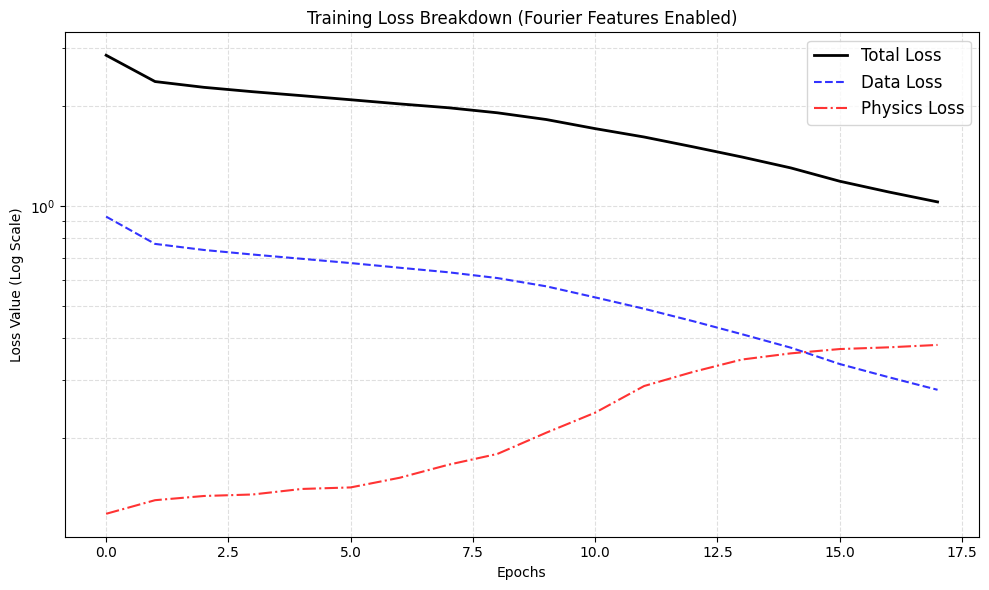

In [48]:
import tensorflow as tf
import numpy as np
import pandas as pd
import time
import os
import matplotlib.pyplot as plt

# ==============================================================================
# 1. โหลดข้อมูลรวม (Combined Data) และเตรียม Dataset
# ==============================================================================
filepath = 'combined_pinn_data.csv'

print(f"กำลังโหลดข้อมูลจาก: {filepath} ...")
if not os.path.exists(filepath):
    raise FileNotFoundError(f"❌ ไม่พบไฟล์ {filepath} กรุณาตรวจสอบชื่อไฟล์ครับ")

df = pd.read_csv(filepath)

# แยก Input (4 ตัวแปร: x, y, z, fan_speed) และ Output
X_raw = df[['x-coordinate', 'y-coordinate', 'z-coordinate', 'fan_speed']].values.astype(np.float32)
U_raw = df['x-velocity'].values.astype(np.float32).reshape(-1, 1)
V_raw = df['y-velocity'].values.astype(np.float32).reshape(-1, 1)
W_raw = df['z-velocity'].values.astype(np.float32).reshape(-1, 1)

# Normalization (ปรับสเกล 0-1)
X_min = tf.constant(X_raw.min(axis=0), dtype=tf.float32)
X_max = tf.constant(X_raw.max(axis=0), dtype=tf.float32)
X_range = X_max - X_min
X_range = tf.where(X_range == 0, tf.ones_like(X_range), X_range)

X_train_norm = (X_raw - X_min.numpy()) / X_range.numpy()

# สร้าง Dataset Pipeline เร่งความเร็ว
BATCH_SIZE = 1024  
dataset = tf.data.Dataset.from_tensor_slices(
    (X_train_norm, U_raw, V_raw, W_raw)
).shuffle(buffer_size=50000).batch(BATCH_SIZE).cache().prefetch(tf.data.AUTOTUNE)

print(f"✔️ โหลดข้อมูลสำเร็จ! Input Shape: {X_train_norm.shape} | Batch Size: {BATCH_SIZE}")

# ==============================================================================
# 2. สร้างโครงสร้างโมเดลขั้นสูง (เพิ่มระบบ Fourier Features)
# ==============================================================================
def build_fourier_model():
    # ใช้ Functional API เพื่อแยกสายข้อมูล
    inputs = tf.keras.Input(shape=(4,))
    
    # แยกพิกัด x, y, z (3 ตัวแรก) และ fan_speed (ตัวสุดท้าย)
    xyz = inputs[:, 0:3]
    fan = inputs[:, 3:4]
    
    # 🔥 สร้าง Fourier Features ให้กับพิกัด x, y, z
    freqs = [1.0, 2.0, 4.0, 8.0] # ระดับความถี่ (ให้ AI เห็นภาพละเอียดขึ้น 4 ระดับ)
    features = [xyz]
    for freq in freqs:
        features.append(tf.math.sin(np.pi * freq * xyz))
        features.append(tf.math.cos(np.pi * freq * xyz))
        
    # นำพิกัดที่แปลงร่างแล้ว มาประกอบร่างรวมกับ fan_speed กลับเหมือนเดิม
    x = tf.concat(features + [fan], axis=-1)
    
    # ส่งเข้าสมองกล (Hidden Layers) แบบ Swish
    x = tf.keras.layers.Dense(128, activation='swish')(x)
    x = tf.keras.layers.Dense(128, activation='swish')(x)
    x = tf.keras.layers.Dense(128, activation='swish')(x)
    x = tf.keras.layers.Dense(128, activation='swish')(x)
    x = tf.keras.layers.Dense(64, activation='swish')(x)
    
    # Output Layer
    outputs = tf.keras.layers.Dense(4)(x) # u, v, w, p
    
    return tf.keras.Model(inputs=inputs, outputs=outputs)

model = build_fourier_model()

# ระบบลด Learning Rate 
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.002,   # ดันเริ่มต้นให้สูงนิดนึงเพื่อกระชากกราฟ
    decay_steps=50000,             
    decay_rate=0.90,
    staircase=False
)

optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule, clipnorm=1.0)

print("Initializing model...")
_ = model(tf.zeros((1, 4))) 
print("Model initialized with Fourier Features!")

# -------------------------------------------------------------
# 🔄 ระบบจัดการ Checkpoint (ล้างความจำเดิมอัตโนมัติ)
# -------------------------------------------------------------
checkpoint_path = 'parametrized_pinn_model.weights.h5'

# 🔥 บังคับลบทิ้ง 100% เพราะเราเปลี่ยนโครงสร้าง Input ใหม่ สมองเดิมใช้ไม่ได้แล้ว
if os.path.exists(checkpoint_path):
    print("\n⚠️ โครงสร้างโมเดลเปลี่ยนไป: กำลังลบความจำเดิมทิ้ง...")
    os.remove(checkpoint_path)
    print("🗑️ ลบไฟล์เรียบร้อยแล้ว! จะเริ่มเทรนใหม่ตั้งแต่ 0")
else:
    print(f"\n✨ จะเป็นการเริ่มเทรนโมเดลใหม่ตั้งแต่ต้น...")

# ==============================================================================
# 3. Physics & Loss Function
# ==============================================================================
rho = 1.225
nu = 1.5e-5

@tf.function
def train_step(X_batch_norm, u_true, v_true, w_true):
    with tf.GradientTape(persistent=True) as tape:
        tape.watch(X_batch_norm)
        
        preds = model(X_batch_norm)
        u, v, w, p = preds[:, 0:1], preds[:, 1:2], preds[:, 2:3], preds[:, 3:4]
        
        du_dX_norm = tape.gradient(u, X_batch_norm)
        dv_dX_norm = tape.gradient(v, X_batch_norm)
        dw_dX_norm = tape.gradient(w, X_batch_norm)
        dp_dX_norm = tape.gradient(p, X_batch_norm)
        
        inv_range_x, inv_range_y, inv_range_z = 1.0/X_range[0], 1.0/X_range[1], 1.0/X_range[2]
        
        u_x = du_dX_norm[:, 0:1] * inv_range_x
        u_y = du_dX_norm[:, 1:2] * inv_range_y
        u_z = du_dX_norm[:, 2:3] * inv_range_z
        v_x = dv_dX_norm[:, 0:1] * inv_range_x
        v_y = dv_dX_norm[:, 1:2] * inv_range_y
        v_z = dv_dX_norm[:, 2:3] * inv_range_z
        w_x = dw_dX_norm[:, 0:1] * inv_range_x
        w_y = dw_dX_norm[:, 1:2] * inv_range_y
        w_z = dw_dX_norm[:, 2:3] * inv_range_z
        p_x = dp_dX_norm[:, 0:1] * inv_range_x
        p_y = dp_dX_norm[:, 1:2] * inv_range_y
        p_z = dp_dX_norm[:, 2:3] * inv_range_z

        u_xx = tape.gradient(du_dX_norm[:, 0:1], X_batch_norm)[:, 0:1] * (inv_range_x**2)
        u_yy = tape.gradient(du_dX_norm[:, 1:2], X_batch_norm)[:, 1:2] * (inv_range_y**2)
        u_zz = tape.gradient(du_dX_norm[:, 2:3], X_batch_norm)[:, 2:3] * (inv_range_z**2)
        v_xx = tape.gradient(dv_dX_norm[:, 0:1], X_batch_norm)[:, 0:1] * (inv_range_x**2)
        v_yy = tape.gradient(dv_dX_norm[:, 1:2], X_batch_norm)[:, 1:2] * (inv_range_y**2)
        v_zz = tape.gradient(dv_dX_norm[:, 2:3], X_batch_norm)[:, 2:3] * (inv_range_z**2)
        w_xx = tape.gradient(dw_dX_norm[:, 0:1], X_batch_norm)[:, 0:1] * (inv_range_x**2)
        w_yy = tape.gradient(dw_dX_norm[:, 1:2], X_batch_norm)[:, 1:2] * (inv_range_y**2)
        w_zz = tape.gradient(dw_dX_norm[:, 2:3], X_batch_norm)[:, 2:3] * (inv_range_z**2)

        res_continuity = u_x + v_y + w_z
        res_ns_x = (u*u_x + v*u_y + w*u_z) + (1/rho)*p_x - nu*(u_xx + u_yy + u_zz)
        res_ns_y = (u*v_x + v*v_y + w*v_z) + (1/rho)*p_y - nu*(v_xx + v_yy + v_zz)
        res_ns_z = (u*w_x + v*w_y + w*w_z) + (1/rho)*p_z - nu*(w_xx + w_yy + w_zz)
        
        loss_data = tf.reduce_mean(tf.square(u_true - u)) + \
                    tf.reduce_mean(tf.square(v_true - v)) + \
                    tf.reduce_mean(tf.square(w_true - w))
        
        loss_physics = tf.reduce_mean(tf.square(res_continuity)) + \
                       tf.reduce_mean(tf.square(res_ns_x)) + \
                       tf.reduce_mean(tf.square(res_ns_y)) + \
                       tf.reduce_mean(tf.square(res_ns_z))
        
        # 🔥 ปรับสมดุลใหม่แบบ Moderate Forcing (ให้ความสำคัญ Data มากขึ้นนิดหน่อย)
        weight_data = 3.0  
        weight_physics = 0.5 
        total_loss = (weight_data * loss_data) + (weight_physics * loss_physics)

    grads = tape.gradient(total_loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    
    del tape 
    
    return total_loss, loss_data, loss_physics

# ==============================================================================
# 4. Training Loop 
# ==============================================================================
INITIAL_EPOCH = 0       
ADDITIONAL_EPOCHS = 3000   
TOTAL_EPOCHS = INITIAL_EPOCH + ADDITIONAL_EPOCHS

PRINT_FREQ = 10     
SAVE_FREQ = 100     

print(f"\n🚀 เริ่มต้นฝึกสอนจากรอบที่ {INITIAL_EPOCH} ไปจนถึงรอบที่ {TOTAL_EPOCHS}")
start_time = time.time()

loss_total_history = []
loss_data_history = []
loss_phys_history = []

try:
    for epoch in range(INITIAL_EPOCH, TOTAL_EPOCHS):
        epoch_loss_total = 0
        epoch_loss_data = 0
        epoch_loss_phys = 0
        steps = 0
        
        for X_batch, u_b, v_b, w_b in dataset:
            l_total, l_data, l_phys = train_step(X_batch, u_b, v_b, w_b)
            epoch_loss_total += l_total
            epoch_loss_data += l_data
            epoch_loss_phys += l_phys
            steps += 1
        
        avg_loss_total = epoch_loss_total / steps
        avg_loss_data = epoch_loss_data / steps
        avg_loss_phys = epoch_loss_phys / steps
        
        loss_total_history.append(avg_loss_total.numpy())
        loss_data_history.append(avg_loss_data.numpy())
        loss_phys_history.append(avg_loss_phys.numpy())
        
        if (epoch + 1) % PRINT_FREQ == 0:
            current_lr = optimizer._decayed_lr(tf.float32).numpy()
            print(f"Epoch {epoch+1:4d}/{TOTAL_EPOCHS} | LR: {current_lr:.6f} | Total: {avg_loss_total:.6f} | Data: {avg_loss_data:.6f} | Phys: {avg_loss_phys:.6f}")

        if (epoch + 1) % SAVE_FREQ == 0:
            model.save_weights(checkpoint_path)

except KeyboardInterrupt:
    print("\n\n⚠️ คุณได้กดหยุดการทำงาน (Interrupted by User)")
    print("กำลังบันทึกน้ำหนักล่าสุด...")

# ==============================================================================
# 5. สรุปผลและวาดกราฟ (Plotting)
# ==============================================================================
model.save_weights(checkpoint_path)
print(f"\n✅ อัปเดตไฟล์โมเดลล่าสุดเรียบร้อยที่: {checkpoint_path}")
print(f"ใช้เวลาเทรนไป: {(time.time() - start_time) / 60:.2f} นาที")

plt.figure(figsize=(10, 6))
plt.plot(range(INITIAL_EPOCH, INITIAL_EPOCH + len(loss_total_history)), loss_total_history, label='Total Loss', color='black', linewidth=2)
plt.plot(range(INITIAL_EPOCH, INITIAL_EPOCH + len(loss_data_history)), loss_data_history, label='Data Loss', color='blue', linestyle='--', alpha=0.8)
plt.plot(range(INITIAL_EPOCH, INITIAL_EPOCH + len(loss_phys_history)), loss_phys_history, label='Physics Loss', color='red', linestyle='-.', alpha=0.8)

plt.yscale('log') 
plt.title('Training Loss Breakdown (Fourier Features Enabled)')
plt.xlabel('Epochs')
plt.ylabel('Loss Value (Log Scale)')
plt.legend(fontsize=12)
plt.grid(True, which="both", ls="--", alpha=0.4)
plt.tight_layout()

# -------------------------------------------------------------
# 🔥 เพิ่มระบบเซฟรูปกราฟ (PNG และ EPS) แบบไม่เซฟทับรูปเดิม
# -------------------------------------------------------------
# ใช้ตัวแปร epoch ที่ได้จากการรัน มาตั้งเป็นชื่อไฟล์ด้วยเลย
filename_base = f'training_loss_fourier_epoch{epoch+1}'

# หรือถ้าอยากให้มีวันที่และเวลาต่อท้ายด้วย (ป้องกันไฟล์ซ้ำ 100%) ใช้โค้ดนี้แทนได้ครับ:
# import datetime
# current_time = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
# filename_base = f'training_loss_fourier_epoch{epoch+1}_{current_time}'

# บันทึกเป็น PNG (ความละเอียดสูง 300 DPI)
plt.savefig(f'{filename_base}.png', dpi=300, bbox_inches='tight', facecolor='white')

# บันทึกเป็น EPS (สำหรับตีพิมพ์เปเปอร์วิจัย)
plt.savefig(f'{filename_base}.eps', format='eps', bbox_inches='tight', facecolor='white')

📌 ความเร็วพัดลมที่มีในชุดข้อมูลคือ: [0.3 0.6 1. ]
กำลังดึงข้อมูล Node ที่มีความเร็วพัดลม = 1.0 ...
✔️ พบข้อมูลทั้งหมด 47822 Nodes


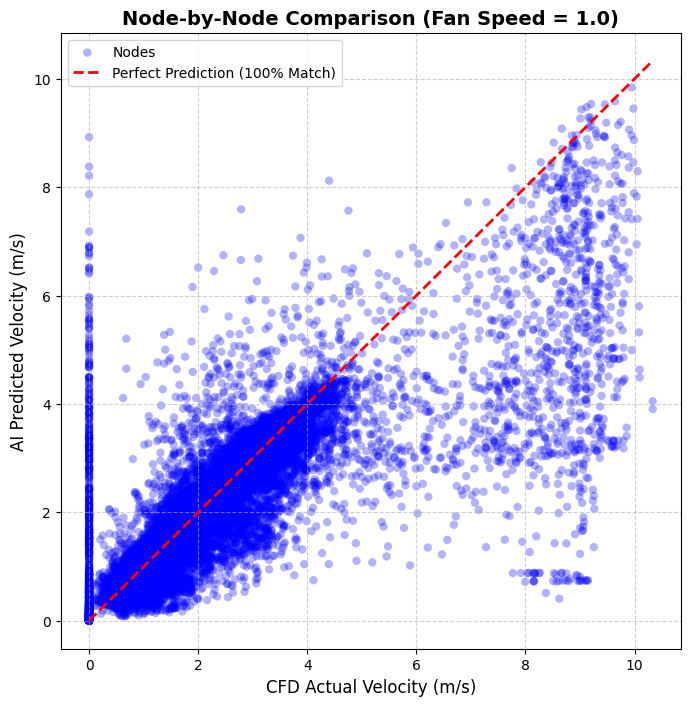

In [25]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

# 0. เช็คก่อนว่าในข้อมูลเรามีพัดลมความเร็วเท่าไหร่บ้าง
available_fans = np.unique(X_raw[:, 3])
print(f"📌 ความเร็วพัดลมที่มีในชุดข้อมูลคือ: {available_fans}")

# 1. เลือกความเร็วพัดลม (เลือกจากตัวเลขที่ปริ้นท์ออกมาด้านบน)
# สมมติว่าในระบบมี 100.0 เราก็ใส่ 100.0 แต่ถ้ามี 1.0 ก็ใส่ 1.0 ครับ
fan_target = available_fans[-1] # ดึงค่าสูงสุดมาใช้ทดสอบอัตโนมัติ

print(f"กำลังดึงข้อมูล Node ที่มีความเร็วพัดลม = {fan_target} ...")

# ใช้ np.isclose แทน == เพื่อป้องกันปัญหาทศนิยมเหลื่อมล้ำ
idx = np.where(np.isclose(X_raw[:, 3], fan_target))[0]

# เช็คความปลอดภัย ถ้าหาไม่เจอให้หยุดการทำงาน
if len(idx) == 0:
    print(f"❌ หาข้อมูลพัดลม {fan_target} ไม่เจอ! โปรดตรวจสอบตัวเลขอีกครั้ง")
else:
    print(f"✔️ พบข้อมูลทั้งหมด {len(idx)} Nodes")

    # ดึงข้อมูลพิกัดและความเร็วลมจริง
    X_nodes = X_raw[idx]
    u_true = U_raw[idx].flatten()
    v_true = V_raw[idx].flatten()
    w_true = W_raw[idx].flatten()
    vel_true = np.sqrt(u_true**2 + v_true**2 + w_true**2)

    # 2. ให้ AI ทำนายผล
    X_nodes_norm = (X_nodes - X_min.numpy()) / X_range.numpy()
    preds = model.predict(tf.cast(X_nodes_norm, tf.float32), batch_size=2048, verbose=0)

    u_pred = preds[:, 0]
    v_pred = preds[:, 1]
    w_pred = preds[:, 2]
    vel_pred = np.sqrt(u_pred**2 + v_pred**2 + w_pred**2)

    # 3. พลอตกราฟ Scatter (True vs Predicted)
    plt.figure(figsize=(8, 8))
    plt.scatter(vel_true, vel_pred, alpha=0.3, color='blue', edgecolors='none', label='Nodes')

    min_val = min(np.min(vel_true), np.min(vel_pred))
    max_val = max(np.max(vel_true), np.max(vel_pred))
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction (100% Match)')

    plt.title(f'Node-by-Node Comparison (Fan Speed = {fan_target})', fontsize=14, fontweight='bold')
    plt.xlabel('CFD Actual Velocity (m/s)', fontsize=12)
    plt.ylabel('AI Predicted Velocity (m/s)', fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

🔍 กำลังประมวลผลเปรียบเทียบ CFD vs PINN ที่ Y = 0.4554 m | พัดลม = 1.0%
✔️ พบจุดทั้งหมด 14343 จุด กำลังให้ AI ทำนายผล...


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


✅ บันทึกรูปภาพสำเร็จแล้ว! สามารถเข้าไปดูไฟล์ได้ที่โฟลเดอร์เดียวกับโค้ดนี้:
   - cfd_vs_pinn_y0.4554_fan1.0.png
   - cfd_vs_pinn_y0.4554_fan1.0.eps



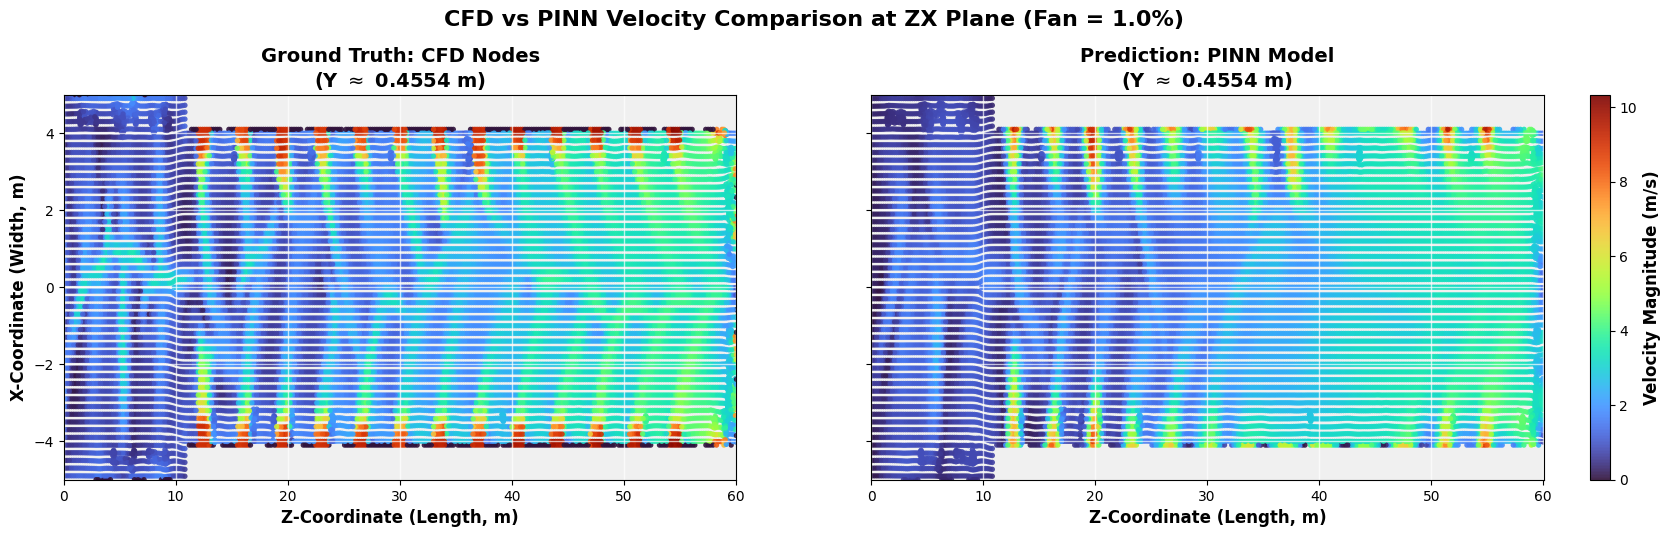

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# ==============================================================================
# 1. ตั้งค่าเป้าหมาย: ระนาบ ZX และ ความเร็วพัดลม
# ==============================================================================
target_y = 0.4554      # ความสูงเป้าหมาย (แกน Y)
tolerance = 0.05       # ระยะเผื่อการดึงจุด CFD (หน่วยเมตร) 

available_fans = np.unique(X_raw[:, 3])
fan_target = available_fans[-1]  

print(f"🔍 กำลังประมวลผลเปรียบเทียบ CFD vs PINN ที่ Y = {target_y} m | พัดลม = {fan_target}%")

# ==============================================================================
# 2. กรองข้อมูลและให้ AI ทำนายผล
# ==============================================================================
# กรองพัดลมและความสูง
idx_fan = np.where(np.isclose(X_raw[:, 3], fan_target))[0]
X_cfd = X_raw[idx_fan]
Vel_cfd = np.sqrt(U_raw[idx_fan].flatten()**2 + V_raw[idx_fan].flatten()**2 + W_raw[idx_fan].flatten()**2)

idx_plane = np.where(np.abs(X_cfd[:, 1] - target_y) <= tolerance)[0]

if len(idx_plane) < 10:
    print(f"❌ พบจุด CFD เพียง {len(idx_plane)} จุด! แนะนำให้เพิ่มค่า tolerance")
else:
    print(f"✔️ พบจุดทั้งหมด {len(idx_plane)} จุด กำลังให้ AI ทำนายผล...")

    # ดึงข้อมูลจริง ณ ระนาบนั้น
    X_plane = X_cfd[idx_plane]
    x_points = X_plane[:, 0]
    z_points = X_plane[:, 2]
    vel_cfd_plane = Vel_cfd[idx_plane]

    # ให้ AI ทำนาย (อย่าลืม Normalize)
    X_plane_norm = (X_plane - X_min.numpy()) / X_range.numpy()
    preds = model.predict(tf.cast(X_plane_norm, tf.float32), batch_size=2048, verbose=0)
    
    u_pred = preds[:, 0]
    v_pred = preds[:, 1]
    w_pred = preds[:, 2]
    vel_pred_plane = np.sqrt(u_pred**2 + v_pred**2 + w_pred**2)

    # หาขอบเขตสีที่ครอบคลุมทั้ง CFD และ PINN เพื่อให้สเกลสีตรงกัน 100%
    vmin_shared = min(np.min(vel_cfd_plane), np.min(vel_pred_plane))
    vmax_shared = max(np.max(vel_cfd_plane), np.max(vel_cfd_plane)) # อิงค่า Max จาก CFD เป็นหลักจะสวยกว่า

    # ==============================================================================
    # 3. พลอตกราฟเปรียบเทียบซ้าย-ขวา
    # ==============================================================================
    fig, axes = plt.subplots(1, 2, figsize=(20, 5), sharey=True)

    # ขอบเขตแกน (Limits)
    x_min, x_max = np.min(X_raw[:, 0]), np.max(X_raw[:, 0])
    z_min, z_max = np.min(X_raw[:, 2]), np.max(X_raw[:, 2])

    # ------------------ [ภาพซ้าย: CFD ของจริง] ------------------
    sc1 = axes[0].scatter(z_points, x_points, c=vel_cfd_plane, cmap='turbo', 
                          s=15, alpha=0.9, edgecolors='none', vmin=vmin_shared, vmax=vmax_shared)
    axes[0].set_title(f'Ansys Simulation: CFD Nodes\n(Y $\\approx$ {target_y} m)', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Z-Coordinate (Length, m)', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('X-Coordinate (Width, m)', fontsize=12, fontweight='bold')
    axes[0].set_xlim(z_min, z_max)
    axes[0].set_ylim(x_min, x_max)
    axes[0].set_facecolor('#f0f0f0') 
    axes[0].grid(color='white', linestyle='-', linewidth=1, alpha=0.7)

    # ------------------ [ภาพขวา: PINN ทำนาย] ------------------
    sc2 = axes[1].scatter(z_points, x_points, c=vel_pred_plane, cmap='turbo', 
                          s=15, alpha=0.9, edgecolors='none', vmin=vmin_shared, vmax=vmax_shared)
    axes[1].set_title(f'Prediction: PINN Model\n(Y $\\approx$ {target_y} m)', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Z-Coordinate (Length, m)', fontsize=12, fontweight='bold')
    axes[1].set_xlim(z_min, z_max)
    axes[1].set_ylim(x_min, x_max)
    axes[1].set_facecolor('#f0f0f0') 
    axes[1].grid(color='white', linestyle='-', linewidth=1, alpha=0.7)

    # ------------------ [แถบสีร่วม] ------------------
    cbar = fig.colorbar(sc2, ax=axes.ravel().tolist(), fraction=0.015, pad=0.03)
    cbar.set_label('Velocity Magnitude (m/s)', fontsize=12, fontweight='bold')

    plt.suptitle(f'CFD vs PINN Velocity Comparison at ZX Plane (Fan = {fan_target}%)', 
                 fontsize=16, fontweight='bold', y=1.05)
    
    # ==============================================================================
    # 4. บันทึกรูปภาพ (Save Figures)
    # ==============================================================================
    # ตั้งชื่อไฟล์ให้สัมพันธ์กับความสูงและความเร็วพัดลม จะได้ไม่เซฟทับกัน
    filename_base = f'cfd_vs_pinn_y{target_y}_fan{fan_target}'
    
    # 💾 บันทึกเป็น PNG (ความละเอียดสูง 300 DPI สำหรับพรีเซนต์/หน้าจอ)
    plt.savefig(f'{filename_base}.png', dpi=300, bbox_inches='tight', facecolor='white')
    
    # 💾 บันทึกเป็น EPS (Vector Graphic สำหรับเปเปอร์วิจัย)
    plt.savefig(f'{filename_base}.eps', format='eps', bbox_inches='tight', facecolor='white')
    
    print(f"✅ บันทึกรูปภาพสำเร็จแล้ว! สามารถเข้าไปดูไฟล์ได้ที่โฟลเดอร์เดียวกับโค้ดนี้:")
    print(f"   - {filename_base}.png")
    print(f"   - {filename_base}.eps\n")
    
    # แสดงภาพบนหน้าจอ
    plt.show()

🔍 กำลังตรวจสอบพิกัดเซนเซอร์ 3 จุด ที่ความเร็วพัดลม = 1.0% ...

📊 ตารางสรุปผลการเปรียบเทียบ (CFD vs PINN):


,Sensor Name,Dist to CFD Node (m),CFD Vel (m/s),PINN Vel (m/s),Abs Error (m/s),Error (%)
0,Sensor_S1,0.0662,2.3766,2.4073,0.0307,1.2918
1,Sensor_S2,0.0767,1.0455,1.3743,0.3288,31.4531
2,Sensor_S3,0.0726,3.0664,1.6516,1.4148,46.1380


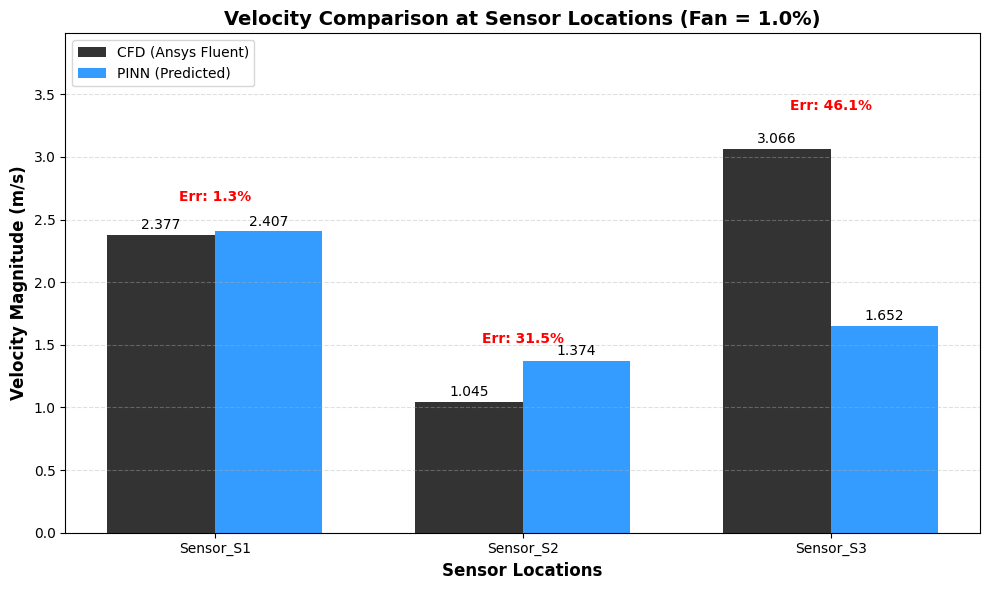

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

# ==============================================================================
# 1. ตั้งค่าพิกัดเซนเซอร์ตามที่ระบุ
# ==============================================================================
# เลือกความเร็วพัดลม (ระบบจะดึงค่าสูงสุดที่มีในชุดข้อมูลมาทดสอบ)
available_fans = np.unique(X_raw[:, 3])
#fan_target = available_fans[-1] 
fan_target = 80.0  # เปลี่ยนตัวเลขตรงนี้เป็น 45.0, 60.0, 75.0 หรือเลขอะไรก็ได้เลยครับ

print(f"🔍 กำลังตรวจสอบพิกัดเซนเซอร์ 3 จุด ที่ความเร็วพัดลม = {fan_target}% ...")

# ใส่พิกัด X, Y, Z ของเซนเซอร์แต่ละจุด
sensors = {
    "Sensor_S1": [0.157458, 0.449922, 36.3381],
    "Sensor_S2": [0.128734, 0.443072, 21.9805],
    "Sensor_S3": [0.335913, 0.407175, 8.19691]
}

# ==============================================================================
# 2. ดึงข้อมูล CFD จริง และให้ PINN ทำนายผล
# ==============================================================================
# กรองเฉพาะข้อมูลพัดลมเป้าหมาย
idx_fan = np.where(np.isclose(X_raw[:, 3], fan_target))[0]
X_cfd = X_raw[idx_fan]
U_cfd = U_raw[idx_fan].flatten()
V_cfd = V_raw[idx_fan].flatten()
W_cfd = W_raw[idx_fan].flatten()
Vel_cfd = np.sqrt(U_cfd**2 + V_cfd**2 + W_cfd**2)

results = []

for name, coords in sensors.items():
    sx, sy, sz = coords
    
    # ก. หาโหนด CFD ที่อยู่ใกล้พิกัดเซนเซอร์นี้มากที่สุด (Nearest Neighbor)
    distances = np.sqrt((X_cfd[:, 0] - sx)**2 + (X_cfd[:, 1] - sy)**2 + (X_cfd[:, 2] - sz)**2)
    closest_idx = np.argmin(distances)
    
    actual_vel = Vel_cfd[closest_idx]
    distance_offset = distances[closest_idx] # เช็คว่าจุด CFD จริงอยู่ห่างจากเซนเซอร์กี่เมตร
    
    # ข. ให้ PINN ทำนายความเร็วลม ณ พิกัดเซนเซอร์ (sx, sy, sz) แบบเป๊ะๆ
    sensor_point = np.array([[sx, sy, sz, fan_target]], dtype=np.float32)
    sensor_norm = (sensor_point - X_min.numpy()) / X_range.numpy()
    
    pred = model.predict(tf.cast(sensor_norm, tf.float32), verbose=0)
    pred_vel = np.sqrt(pred[0, 0]**2 + pred[0, 1]**2 + pred[0, 2]**2)
    
    # ค. คำนวณ Error (ปรับเงื่อนไขป้องกันหารด้วยศูนย์)
    abs_error = abs(pred_vel - actual_vel)
    error_percent = (abs_error / actual_vel) * 100 if actual_vel > 0.01 else 0.0
    
    results.append({
        "Sensor Name": name,
        "Dist to CFD Node (m)": distance_offset,
        "CFD Vel (m/s)": actual_vel,
        "PINN Vel (m/s)": pred_vel,
        "Abs Error (m/s)": abs_error,
        "Error (%)": error_percent
    })

# ==============================================================================
# 3. แสดงผลตารางและวาดกราฟแท่ง (Bar Chart)
# ==============================================================================
df_results = pd.DataFrame(results)
print("\n📊 ตารางสรุปผลการเปรียบเทียบ (CFD vs PINN):")
display(df_results.round(4))

# เตรียมพลอตกราฟแท่งคู่
plt.figure(figsize=(10, 6))
x_pos = np.arange(len(sensors))
width = 0.35

cfd_vals = df_results['CFD Vel (m/s)']
pinn_vals = df_results['PINN Vel (m/s)']
labels = df_results['Sensor Name']

bars1 = plt.bar(x_pos - width/2, cfd_vals, width, label='CFD (Ansys Fluent)', color='black', alpha=0.8)
bars2 = plt.bar(x_pos + width/2, pinn_vals, width, label='PINN (Predicted)', color='dodgerblue', alpha=0.9)

plt.title(f'Velocity Comparison at Sensor Locations (Fan = {fan_target}%)', fontsize=14, fontweight='bold')
plt.xlabel('Sensor Locations', fontsize=12, fontweight='bold')
plt.ylabel('Velocity Magnitude (m/s)', fontsize=12, fontweight='bold')
plt.xticks(x_pos, labels)
plt.legend(loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.4)

# เติมตัวเลขกำกับบนแท่งกราฟ
for bar in bars1:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.3f}', ha='center', va='bottom', fontsize=10)
    
for i, bar in enumerate(bars2):
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.3f}', ha='center', va='bottom', fontsize=10)
    
    # เติมข้อความบอก % Error สีแดงไว้ด้านบนสุดของแท่งที่สูงกว่า
    err_pct = df_results['Error (%)'].iloc[i]
    max_h = max(cfd_vals.iloc[i], pinn_vals.iloc[i])
    plt.text(x_pos[i], max_h + (max_h*0.1), f'Err: {err_pct:.1f}%', ha='center', color='red', fontweight='bold')

# ปรับเพดานแกน Y ให้มีที่ว่างสำหรับตัวหนังสือ
plt.ylim(0, max(max(cfd_vals), max(pinn_vals)) * 1.3)
plt.tight_layout()
plt.show()

🔍 กำลังประมวลผลไฟล์: ansys_results_fan80.csv ...
✔️ โหลดข้อมูล CFD สำเร็จ! พบโหนด 47822 จุด

📊 ผลการทดสอบ Unseen Data (Fan 80%):


,Sensor Name,"Target (X,Y,Z)",CFD Vel (m/s),PINN Vel (m/s),Error (%)
0,Sensor_S1,"(0.16, 0.45, 36.34)",1.6495,1.8443,11.8120
1,Sensor_S2,"(0.13, 0.44, 21.98)",0.9321,0.9268,0.5651
2,Sensor_S3,"(0.34, 0.41, 8.20)",1.9025,1.3930,26.7784


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.



✅ บันทึกรูปภาพสำเร็จ! ตรวจสอบไฟล์ได้ที่:
   - validation_sensor_fan80.png
   - validation_sensor_fan80.eps



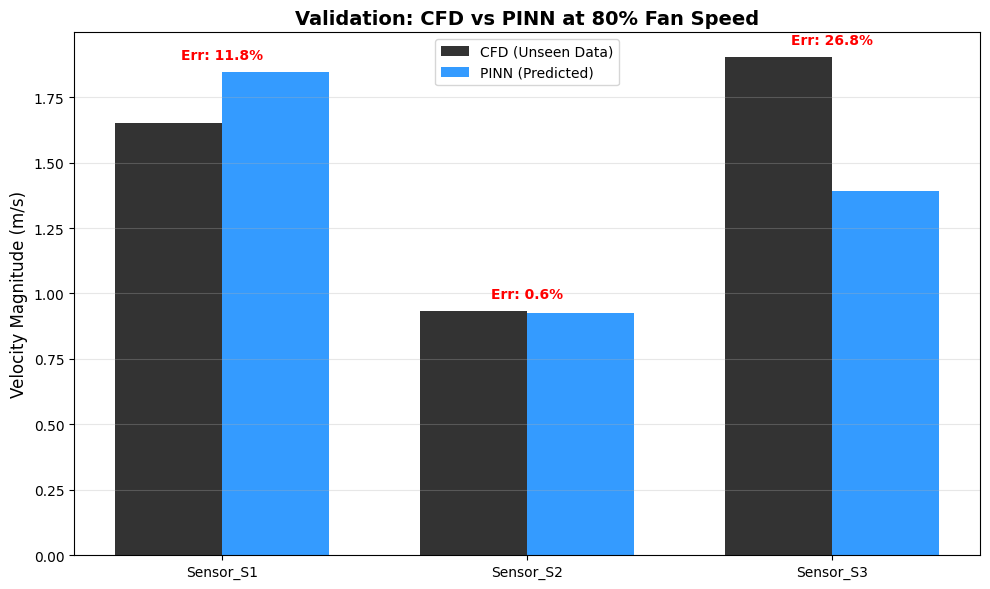

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

# ==============================================================================
# 1. โหลดไฟล์และล้างชื่อคอลัมน์ (Clean Column Names)
# ==============================================================================
file_path = 'ansys_results_fan80.csv'
fan_target = 0.8

print(f"🔍 กำลังประมวลผลไฟล์: {file_path} ...")

try:
    df_new = pd.read_csv(file_path)
    
    # 🔥 ทีเด็ด: ลบช่องว่างหน้า-หลังชื่อคอลัมน์ทั้งหมดออก
    df_new.columns = df_new.columns.str.strip()
    
    # ตอนนี้เราเรียกใช้ชื่อปกติได้เลยครับ
    x_coords = df_new['x-coordinate'].values
    y_coords = df_new['y-coordinate'].values
    z_coords = df_new['z-coordinate'].values
    
    u_vel = df_new['x-velocity'].values
    v_vel = df_new['y-velocity'].values
    w_vel = df_new['z-velocity'].values
    
    X_cfd_new = np.stack([x_coords, y_coords, z_coords], axis=1)
    Vel_cfd_new = np.sqrt(u_vel**2 + v_vel**2 + w_vel**2)
    
    print(f"✔️ โหลดข้อมูล CFD สำเร็จ! พบโหนด {len(df_new)} จุด")

    # ==============================================================================
    # 2. ตั้งค่าพิกัดเซนเซอร์ตามที่อาจารย์ระบุ
    # ==============================================================================
    sensors = {
        "Sensor_S1": [0.157458, 0.449922, 36.3381],
        "Sensor_S2": [0.128734, 0.443072, 21.9805],
        "Sensor_S3": [0.335913, 0.407175, 8.19691]
    }

    results = []

    for name, coords in sensors.items():
        sx, sy, sz = coords
        
        # หาโหนด CFD ที่ใกล้พิกัดเซนเซอร์ที่สุด
        distances = np.sqrt((X_cfd_new[:, 0] - sx)**2 + (X_cfd_new[:, 1] - sy)**2 + (X_cfd_new[:, 2] - sz)**2)
        closest_idx = np.argmin(distances)
        
        actual_vel = Vel_cfd_new[closest_idx]
        
        # ให้ PINN ทำนายผล (Unseen Data)
        sensor_point = np.array([[sx, sy, sz, fan_target]], dtype=np.float32)
        sensor_norm = (sensor_point - X_min.numpy()) / X_range.numpy()
        
        pred = model.predict(tf.cast(sensor_norm, tf.float32), verbose=0)
        pred_vel = np.sqrt(pred[0, 0]**2 + pred[0, 1]**2 + pred[0, 2]**2)
        
        # คำนวณ Error
        abs_error = abs(pred_vel - actual_vel)
        error_percent = (abs_error / actual_vel) * 100 if actual_vel > 0.01 else 0.0
        
        results.append({
            "Sensor Name": name,
            "Target (X,Y,Z)": f"({sx:.2f}, {sy:.2f}, {sz:.2f})",
            "CFD Vel (m/s)": actual_vel,
            "PINN Vel (m/s)": pred_vel,
            "Error (%)": error_percent
        })

    # ==============================================================================
    # 3. สรุปผลและวาดกราฟ
    # ==============================================================================
    df_results = pd.DataFrame(results)
    print("\n📊 ผลการทดสอบ Unseen Data (Fan 80%):")
    display(df_results.round(4))

    plt.figure(figsize=(10, 6))
    x_pos = np.arange(len(sensors))
    width = 0.35

    bars1 = plt.bar(x_pos - width/2, df_results['CFD Vel (m/s)'], width, label='CFD (Unseen Data)', color='black', alpha=0.8)
    bars2 = plt.bar(x_pos + width/2, df_results['PINN Vel (m/s)'], width, label='PINN (Predicted)', color='dodgerblue', alpha=0.9)

    plt.title(f'Validation: CFD vs PINN at 80% Fan Speed', fontsize=14, fontweight='bold')
    plt.xticks(x_pos, df_results['Sensor Name'])
    plt.ylabel('Velocity Magnitude (m/s)', fontsize=12)
    plt.legend()
    plt.grid(axis='y', alpha=0.3)

    # ใส่เลข % Error กำกับ
    for i, bar in enumerate(bars2):
        err = df_results['Error (%)'].iloc[i]
        # หาความสูงที่สูงกว่าระหว่าง CFD กับ PINN เพื่อวางตัวหนังสือให้ไม่ทับแท่ง
        max_h = max(df_results['CFD Vel (m/s)'].iloc[i], df_results['PINN Vel (m/s)'].iloc[i])
        plt.text(x_pos[i], max_h + 0.05, f'Err: {err:.1f}%', ha='center', color='red', fontweight='bold')

    plt.tight_layout()

    # ==============================================================================
    # 4. 🔥 ระบบบันทึกรูปภาพ (Save Figures as .png and .eps)
    # ==============================================================================
    filename_base = f'validation_sensor_fan80'
    
    # บันทึกเป็น PNG (300 DPI)
    plt.savefig(f'{filename_base}.png', dpi=300, bbox_inches='tight', facecolor='white')
    
    # บันทึกเป็น EPS (Vector Graphic)
    plt.savefig(f'{filename_base}.eps', format='eps', bbox_inches='tight', facecolor='white')
    
    print(f"\n✅ บันทึกรูปภาพสำเร็จ! ตรวจสอบไฟล์ได้ที่:")
    print(f"   - {filename_base}.png")
    print(f"   - {filename_base}.eps\n")

    # แสดงภาพบนหน้าจอ
    plt.show()

except Exception as e:
    print(f"❌ เกิดข้อผิดพลาด: {e}")